# Rolling Walk-Forward (Experiment 3) -- EDA

Visualizes the output of `run_rolling_walk_forward_experiment`
(`thesis.experiments.rolling_walk_forward`): for each shortlisted config, the
timeline is walked one window at a time, mining+fitting from scratch on the
*full* window `Wi` and evaluating on `W(i+1)`, then discarding and repeating
-- the "always retrain" anchor, in contrast to `temporal_decay_eda.ipynb`'s
frozen-model decay curve (Experiment 2). This notebook draws the per-step
metric/FPR trajectory (flat vs. trending vs. occasional dips), the
walk-forward summary table (mean/std per config -- the headline "how good is
this in general" number), and, if a matching Experiment 2 run is available
for the same scenario, the gap between Experiment 2's frozen-decay endpoint
and Experiment 3's always-retrain steady state -- exactly the number
Experiment 4's drift monitor gets compared against.

In [27]:
from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from thesis.paths import ARTIFACTS_DIR

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Settings

Edit and re-run -- nothing past this cell needs to change.

In [28]:
SCENARIO = "cscas"
RUN_ID = None  # None -> latest rolling_walk_forward run dir for SCENARIO

PRIMARY_METRIC = "auc"  # which metric to draw as the main per-step trajectory
LINE_COLOR = "#4477AA"

# Section 3 (comparison with Experiment 2) needs a matching temporal_decay
# run for the same scenario -- same shortlist, ideally. Set to False to skip
# that section, or pin a specific run id instead of using the latest.
COMPARE_TO_TEMPORAL_DECAY = True
TEMPORAL_DECAY_RUN_ID = None  # None -> latest temporal_decay run dir for SCENARIO

In [29]:
CONFIG_COLS = ["feature_set", "mining_setting", "granularity", "model"]

sweep_dir = ARTIFACTS_DIR / "experiments" / "rolling_walk_forward" / SCENARIO
# Only consider run directories -- sweep_dir also holds
# _derived_shortlist.csv (written by --structural-configs runs), and
# sorting unfiltered would pick that file as "latest" since "_" sorts after
# digits, then crash trying to treat it as a directory.
run_dirs = [p for p in sweep_dir.iterdir() if p.is_dir()]
run_dir = sweep_dir / RUN_ID if RUN_ID else sorted(run_dirs)[-1]

per_step = pd.read_csv(run_dir / "per_step_results.csv")
walk_forward_summary = pd.read_csv(run_dir / "walk_forward_summary.csv")

print(f"Loaded from {run_dir}")
print(f"per_step_results:      {len(per_step)} rows")
print(f"walk_forward_summary:  {len(walk_forward_summary)} rows")
per_step.head()

Loaded from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/rolling_walk_forward/cscas/20260713_232856
per_step_results:      63 rows
walk_forward_summary:  7 rows


,scenario,feature_set,mining_setting,granularity,model,n_windows,threshold_mode,step_i,threshold,mining_cache_hit,n_alert_groups,n_attack,auc,accuracy,precision,recall,f1,tp,fp,tn,fn,fpr
0,cscas,symbolic,gr3_md1_mda4,0.1,logreg,10,fixed,0,0.5,True,139532,1494,0.998968,0.995944,0.725243,1.000000,0.840743,1494,566,137472,0,0.004100
1,cscas,symbolic,gr3_md1_mda4,0.1,logreg,10,fixed,1,0.5,True,139532,1810,0.999491,0.997226,0.840920,0.969613,0.900693,1755,332,137390,55,0.002411
2,cscas,symbolic,gr3_md1_mda4,0.1,logreg,10,fixed,2,0.5,False,139532,3253,0.985530,0.990497,0.739260,0.915155,0.817857,2977,1050,135229,276,0.007705
3,cscas,symbolic,gr3_md1_mda4,0.1,logreg,10,fixed,3,0.5,False,139532,2665,0.988609,0.995721,0.834195,0.968480,0.896336,2581,513,136354,84,0.003748
4,cscas,symbolic,gr3_md1_mda4,0.1,logreg,10,fixed,4,0.5,False,139532,1684,0.999253,0.996782,0.794188,0.989905,0.881311,1667,432,137416,17,0.003134


## 1. Metric over step

One small-multiple per config: metric vs. `step_i` (the training window
index `Wi`, evaluated on `W(i+1)`). Unlike Experiment 2's decay curve, this
is *not* expected to trend downward -- since every step retrains from
scratch, the useful question is whether performance is flat (stable
generalization), trending (a systematic drift the rolling protocol can't
fully absorb), or has occasional dips tied to specific time periods. That
last pattern is exactly the "normal" step-to-step variance Experiment 4's
drift-triggering logic needs to be calibrated against, so it doesn't fire on
noise.

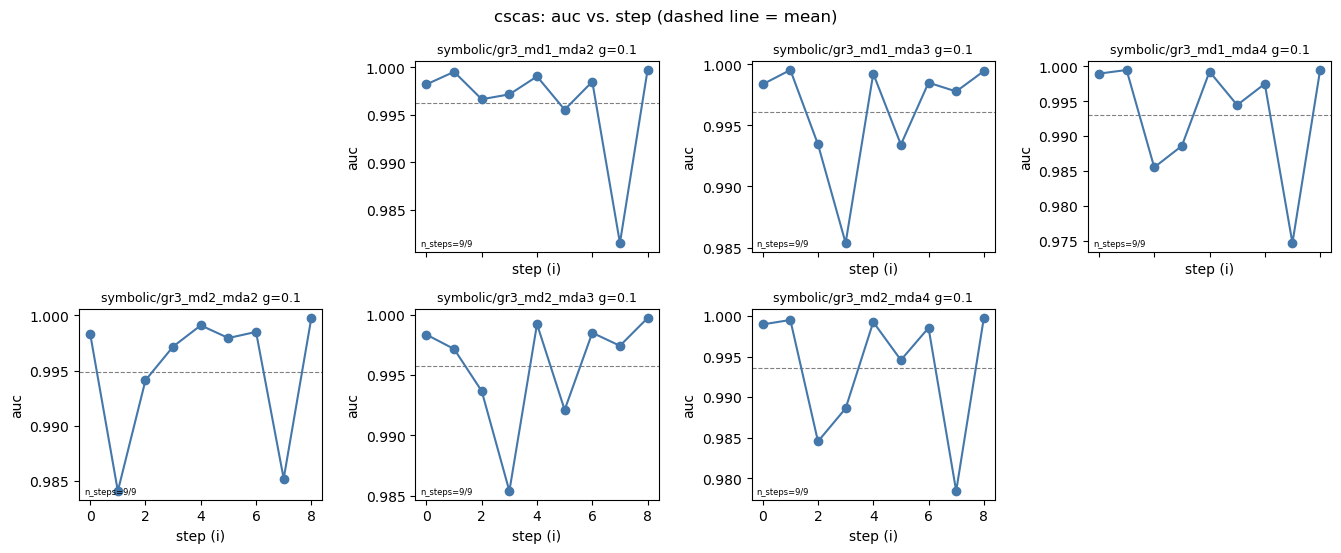

In [30]:
def config_label(row) -> str:
    return f"{row['feature_set']}/{row['mining_setting']} g={row['granularity']:g}"


def ordered_configs(df: pd.DataFrame) -> pd.DataFrame:
    # Ordered by granularity (not first-appearance) so configs at the same
    # granularity land next to each other for visibility.
    return (
        df[CONFIG_COLS].drop_duplicates()
        .sort_values(["granularity", "feature_set", "mining_setting"])
        .reset_index(drop=True)
    )


def plot_metric_over_step(metric: str, title: str) -> None:
    configs = ordered_configs(per_step)
    n = len(configs)
    ncols = 4
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.4 * ncols, 2.8 * nrows), squeeze=False, sharex=True
    )

    for i, cfg_row in configs.iterrows():
        ax = axes[i // ncols][i % ncols]
        mask = (per_step[CONFIG_COLS] == cfg_row).all(axis=1)
        sub = per_step[mask].sort_values("step_i")
        if sub.empty or metric not in sub.columns:
            ax.axis("off")
            continue

        ax.plot(sub["step_i"], sub[metric], "o-", color=LINE_COLOR, zorder=2)
        mean_val = sub[metric].mean()
        if pd.notna(mean_val):
            ax.axhline(mean_val, color="grey", linewidth=0.8, linestyle="--", zorder=1)

        ax.set_title(config_label(cfg_row), fontsize=9)
        ax.text(
            0.02, 0.02, f"n_steps={sub[metric].notna().sum()}/{len(sub)}",
            transform=ax.transAxes, fontsize=6, va="bottom",
        )
        ax.set_xlabel("step (i)")
        ax.set_ylabel(metric)

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    fig.suptitle(title)
    fig.tight_layout()


plot_metric_over_step(PRIMARY_METRIC, f"{SCENARIO}: {PRIMARY_METRIC} vs. step (dashed line = mean)")

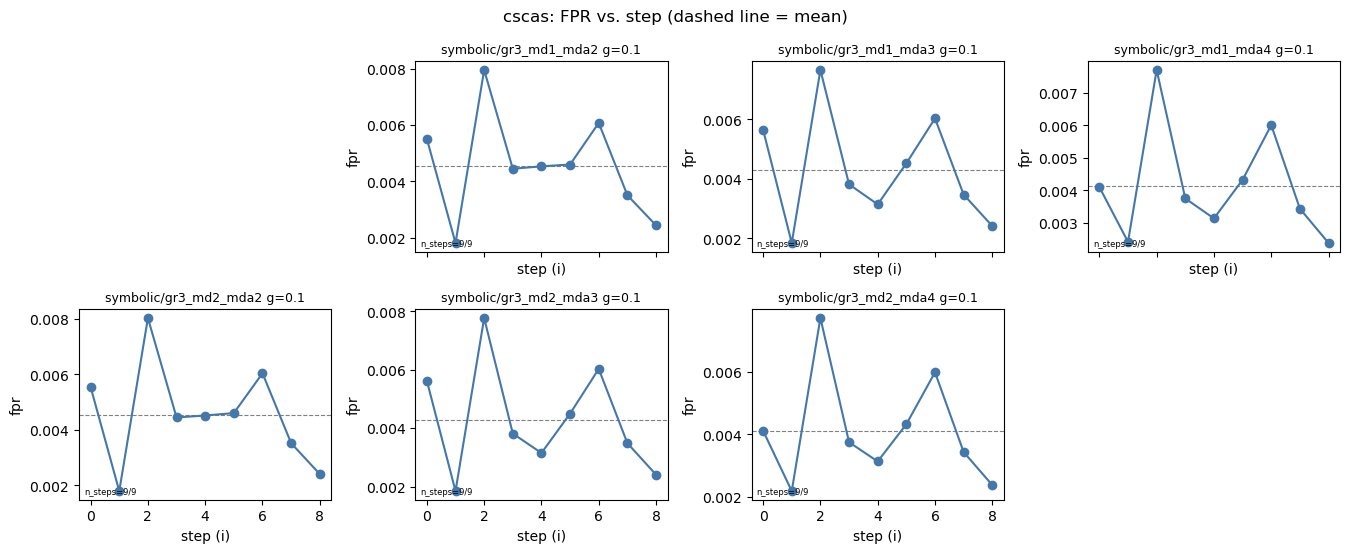

In [31]:
plot_metric_over_step("fpr", f"{SCENARIO}: FPR vs. step (dashed line = mean)")

## 2. Walk-forward summary (headline number)

Mean and std of `auc`, `f1`, and `fpr` across every step actually run, one
row per config -- the "how good is this config in general use" number this
experiment exists to produce, sorted by the primary metric's mean
(descending). Directly comparable across configs, and directly
contrastable with Experiment 2's fixed-source-window results (section 3
below).

In [32]:
sort_col = f"{PRIMARY_METRIC}_mean"
summary_sorted = (
    walk_forward_summary.sort_values(sort_col, ascending=False)
    if sort_col in walk_forward_summary.columns
    else walk_forward_summary
)
summary_sorted

,feature_set,mining_setting,granularity,model,auc_mean,auc_std,f1_mean,f1_std,fpr_mean,fpr_std,n_steps
1,symbolic,gr3_md1_mda2,0.1,logreg,0.996219,0.005685,0.855562,0.045559,0.004543,0.001871,9
2,symbolic,gr3_md1_mda3,0.1,logreg,0.996122,0.004688,0.861974,0.046391,0.004281,0.001869,9
5,symbolic,gr3_md2_mda3,0.1,logreg,0.995740,0.004648,0.862043,0.046591,0.004291,0.001893,9
4,symbolic,gr3_md2_mda2,0.1,logreg,0.994909,0.006027,0.855582,0.045695,0.004547,0.001892,9
0,baseline,NaN,0.1,logreg,0.994644,0.010673,0.805209,0.060273,0.007009,0.002178,9
6,symbolic,gr3_md2_mda4,0.1,logreg,0.993569,0.007876,0.868069,0.038050,0.004113,0.001762,9
3,symbolic,gr3_md1_mda4,0.1,logreg,0.993105,0.008597,0.867561,0.036788,0.004138,0.001732,9


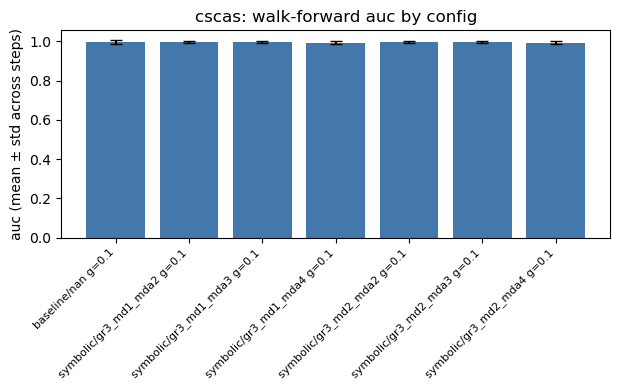

In [33]:
mean_col, std_col = f"{PRIMARY_METRIC}_mean", f"{PRIMARY_METRIC}_std"
# Plotted in granularity order (not the table's performance-rank order above)
# so configs at the same granularity are visually grouped.
plot_order = summary_sorted.sort_values(["granularity", "feature_set", "mining_setting"]).reset_index(drop=True)
labels = plot_order.apply(config_label, axis=1)

fig, ax = plt.subplots(figsize=(max(6, 0.9 * len(plot_order)), 4))
ax.bar(labels, plot_order[mean_col], yerr=plot_order[std_col], color=LINE_COLOR, capsize=4)
ax.set_ylabel(f"{PRIMARY_METRIC} (mean ± std across steps)")
ax.set_title(f"{SCENARIO}: walk-forward {PRIMARY_METRIC} by config")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
fig.tight_layout()

## 3. Comparison with Experiment 2 (frozen decay vs. always-retrain steady state)

Experiment 2 froze a schema+model at window 0 and let it decay; Experiment 3
retrains at every step. The gap between Experiment 2's decayed endpoint
(`{metric}_at_h{h_max}`, its last horizon actually reached) and Experiment
3's steady-state mean (`{metric}_mean` above) is the improvement a perfect
always-retrain policy buys over never retraining -- the number Experiment
4's drift monitor gets compared against. Also shown: Experiment 2's `h=0`
score (`{metric}_at_h0`, its best case, before any decay), as an upper-bound
reference. Requires a `temporal_decay` run for the same `SCENARIO`, ideally
from the same shortlist -- skipped gracefully if none is found.

In [34]:
comparison = None
if COMPARE_TO_TEMPORAL_DECAY:
    td_dir = ARTIFACTS_DIR / "experiments" / "temporal_decay" / SCENARIO
    # Only consider run directories -- td_dir also holds
    # _derived_shortlist.csv (written by --structural-configs runs); "_"
    # sorts after digits, so an unfiltered sort/`any()` would treat that
    # file as the latest run and then crash reading it as a directory.
    td_run_dirs = [p for p in td_dir.iterdir() if p.is_dir()] if td_dir.exists() else []
    if td_run_dirs:
        td_run_dir = (
            td_dir / TEMPORAL_DECAY_RUN_ID if TEMPORAL_DECAY_RUN_ID else sorted(td_run_dirs)[-1]
        )
        decay_summary_path = td_run_dir / "decay_summary.csv"
        if decay_summary_path.exists():
            decay_summary = pd.read_csv(decay_summary_path)
            decay_summary[f"{PRIMARY_METRIC}_at_h_max"] = decay_summary.apply(
                lambda r: r.get(f"{PRIMARY_METRIC}_at_h{int(r['h_max'])}", np.nan), axis=1
            )
            comparison = walk_forward_summary.merge(
                decay_summary[CONFIG_COLS + [f"{PRIMARY_METRIC}_at_h0", f"{PRIMARY_METRIC}_at_h_max"]],
                on=CONFIG_COLS,
                how="inner",
            )
            comparison["always_retrain_gain"] = (
                comparison[f"{PRIMARY_METRIC}_mean"] - comparison[f"{PRIMARY_METRIC}_at_h_max"]
            )
            print(f"Compared against {td_run_dir}")
            print(
                f"{len(comparison)}/{len(walk_forward_summary)} configs matched by "
                "(feature_set, mining_setting, granularity, model)"
            )
        else:
            print(f"No decay_summary.csv found at {td_run_dir} -- skipping comparison")
    else:
        print(f"No temporal_decay runs found at {td_dir} -- skipping comparison")
else:
    print("COMPARE_TO_TEMPORAL_DECAY is False -- skipping comparison")

comparison

Compared against /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/temporal_decay/cscas/20260713_222406
7/7 configs matched by (feature_set, mining_setting, granularity, model)


,feature_set,mining_setting,granularity,model,auc_mean,auc_std,f1_mean,f1_std,fpr_mean,fpr_std,n_steps,auc_at_h0,auc_at_h_max,always_retrain_gain
0,baseline,NaN,0.1,logreg,0.994644,0.010673,0.805209,0.060273,0.007009,0.002178,9,0.998037,0.995840,-0.001196
1,symbolic,gr3_md1_mda2,0.1,logreg,0.996219,0.005685,0.855562,0.045559,0.004543,0.001871,9,0.998491,0.993924,0.002295
2,symbolic,gr3_md1_mda3,0.1,logreg,0.996122,0.004688,0.861974,0.046391,0.004281,0.001869,9,0.989019,0.980194,0.015928
3,symbolic,gr3_md1_mda4,0.1,logreg,0.993105,0.008597,0.867561,0.036788,0.004138,0.001732,9,0.998673,0.966782,0.026323
4,symbolic,gr3_md2_mda2,0.1,logreg,0.994909,0.006027,0.855582,0.045695,0.004547,0.001892,9,0.984275,0.991898,0.003011
5,symbolic,gr3_md2_mda3,0.1,logreg,0.995740,0.004648,0.862043,0.046591,0.004291,0.001893,9,0.983438,0.984299,0.011441
6,symbolic,gr3_md2_mda4,0.1,logreg,0.993569,0.007876,0.868069,0.038050,0.004113,0.001762,9,0.983280,0.963773,0.029795


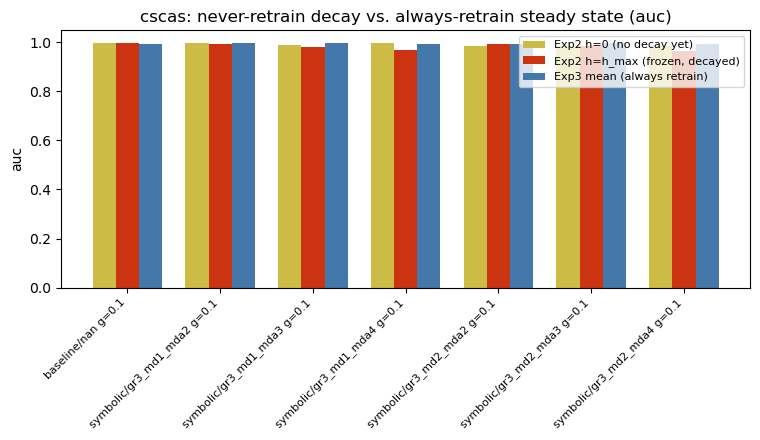

In [35]:
if comparison is not None and not comparison.empty:
    plot_order = comparison.sort_values(["granularity", "feature_set", "mining_setting"]).reset_index(drop=True)
    labels = plot_order.apply(config_label, axis=1)
    x = np.arange(len(plot_order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, 1.1 * len(plot_order)), 4.5))
    ax.bar(x - width, plot_order[f"{PRIMARY_METRIC}_at_h0"], width, label="Exp2 h=0 (no decay yet)", color="#CCBB44")
    ax.bar(x, plot_order[f"{PRIMARY_METRIC}_at_h_max"], width, label="Exp2 h=h_max (frozen, decayed)", color="#CC3311")
    ax.bar(x + width, plot_order[f"{PRIMARY_METRIC}_mean"], width, label="Exp3 mean (always retrain)", color=LINE_COLOR)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(PRIMARY_METRIC)
    ax.set_title(f"{SCENARIO}: never-retrain decay vs. always-retrain steady state ({PRIMARY_METRIC})")
    ax.legend(fontsize=8)
    fig.tight_layout()
else:
    print("No comparison data to plot.")